In [5]:
import os
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [6]:
# ── Config ─────────────────────────────────────────────────────────────────
DATA_PATH  = "data/Dataset/Combined Data/Combined_dataset.csv"
OUTPUT_DIR = "output"
FEATURES = [
    "Ammonia (mg/l)",
    "Biochemical Oxygen Demand (mg/l)",
    "Dissolved Oxygen (mg/l)",
    "Orthophosphate (mg/l)",
    "pH (ph units)",
    "Temperature (cel)",
    "Nitrogen (mg/l)",
    "Nitrate (mg/l)",
]
TARGET      = "CCME_Values"   # numeric WQI score (0–100); CCME_WQI is the category label
RANDOM_SEED = 42
TEST_SIZE   = 0.1
VAL_SIZE    = 0.1

os.makedirs(OUTPUT_DIR, exist_ok=True)

In [7]:
# ── 1. Load data ─────────────────────────────────────────────────────────────
df = pd.read_csv(DATA_PATH)
print(f"Dataset shape: {df.shape}")

X = df[FEATURES].values
y = df[TARGET].values.astype(float)   # continuous WQI score (0–100)

print(f"\nTarget statistics:")
print(f"  Mean:  {y.mean():.2f}")
print(f"  Std:   {y.std():.2f}")
print(f"  Min:   {y.min():.2f}")
print(f"  Max:   {y.max():.2f}")

Dataset shape: (2827977, 14)

Target statistics:
  Mean:  85.05
  Std:   17.65
  Min:   31.30
  Max:   100.00


In [8]:
# ── 2. IQR outlier removal (1.5× inner fence, matching baseline) ─────────────
df_clean = df[FEATURES + [TARGET]].copy()
for col in FEATURES:
    Q1, Q3 = df_clean[col].quantile(0.25), df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    df_clean = df_clean[(df_clean[col] >= Q1 - 1.5 * IQR) & (df_clean[col] <= Q3 + 1.5 * IQR)]

X = df_clean[FEATURES].values
y = df_clean[TARGET].values.astype(float)
print(f"After outlier removal: {len(df_clean):,} rows  (removed {len(df) - len(df_clean):,})")

After outlier removal: 1,489,079 rows  (removed 1,338,898)


In [10]:
# ── 3. Train / val / test split ──────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_SEED
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=VAL_SIZE, random_state=RANDOM_SEED
)
print(f"Train: {X_train.shape[0]:,}  Val: {X_val.shape[0]:,}  Test: {X_test.shape[0]:,}")

Train: 1,206,153  Val: 134,018  Test: 148,908


In [ ]:
# ── 4. Feature scaling ──────────────────────────────────────────────────────
# (merged into cell 5 — this cell intentionally left as a pass-through)
pass

In [12]:
# ── 5. Scale features + target ───────────────────────────────────────────────
from sklearn.preprocessing import MinMaxScaler

scaler   = StandardScaler()
X_train  = scaler.fit_transform(X_train)
X_val    = scaler.transform(X_val)
X_test   = scaler.transform(X_test)

y_scaler  = MinMaxScaler()
y_train_s = y_scaler.fit_transform(y_train.reshape(-1, 1)).flatten()
y_val_s   = y_scaler.transform(y_val.reshape(-1, 1)).flatten()
# y_test stays unscaled — we inverse-transform predictions for evaluation
print("Features: StandardScaler | Target: MinMaxScaler (fit on train only)")

Features: StandardScaler | Target: MinMaxScaler (fit on train only)


In [ ]:
# ── 6. Build regression model ────────────────────────────────────────────────
tf.random.set_seed(RANDOM_SEED)

model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(len(FEATURES),)),

    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.3),

    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.3),

    tf.keras.layers.Dense(32, activation="relu"),
    tf.keras.layers.Dropout(0.2),

    tf.keras.layers.Dense(1),   # linear output — continuous WQI score
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="mse",
    metrics=["mae"],
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         1,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,289 (48.00 KB)

 Trainable params: 11,905 (46.50 KB)

 Non-trainable params: 384 (1.50 KB)

In [ ]:
# ── 7. Callbacks ────────────────────────────────────────────────────────────
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss", patience=10, restore_best_weights=True
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss", factor=0.5, patience=5, min_lr=1e-6, verbose=1
    ),
]

In [ ]:
# ── 8. Train ─────────────────────────────────────────────────────────────────
history = model.fit(
    X_train, y_train_s,
    validation_data=(X_val, y_val_s),
    epochs=100,
    batch_size=256,
    callbacks=callbacks,
    verbose=1,
)

In [ ]:
# ── 9. Evaluate ──────────────────────────────────────────────────────────────
y_pred_s = model.predict(X_test, verbose=0).flatten()
y_pred   = y_scaler.inverse_transform(y_pred_s.reshape(-1, 1)).flatten()

mse  = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae  = mean_absolute_error(y_test, y_pred)
r2   = r2_score(y_test, y_pred)

print(f"MSE:  {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAE:  {mae:.4f}")
print(f"R²:   {r2:.4f}")

# Actual vs predicted plot
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(y_test, y_pred, alpha=0.2, s=5, color="steelblue")
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
ax.plot(lims, lims, "r--", linewidth=1.5, label="Perfect prediction")
ax.set_xlabel("Actual WQI")
ax.set_ylabel("Predicted WQI")
ax.set_title(f"Actual vs Predicted — ANN (R²={r2:.4f})")
ax.legend()
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/actual_vs_predicted_ann.png", dpi=150)
plt.show()

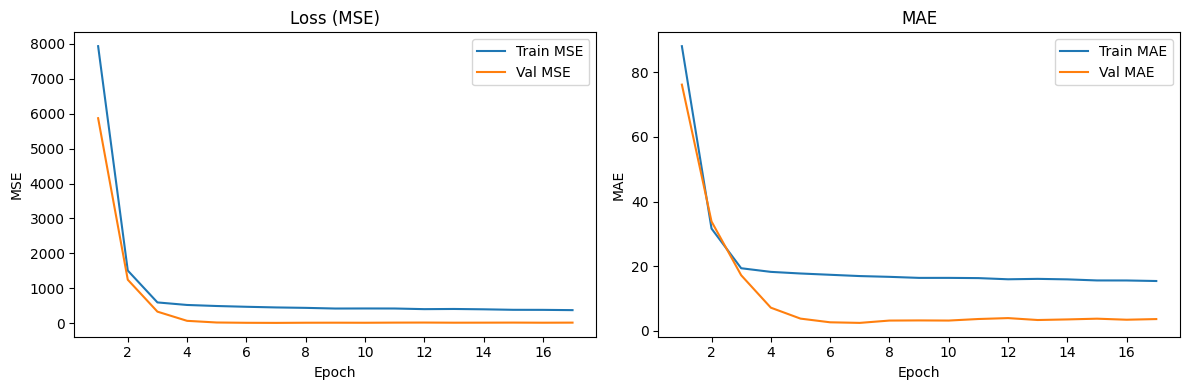

Saved to output/training_curves.png


In [ ]:
# ── 10. Training curves ───────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
epochs_ran = range(1, len(history.history["loss"]) + 1)

ax1.plot(epochs_ran, history.history["loss"],     label="Train MSE")
ax1.plot(epochs_ran, history.history["val_loss"], label="Val MSE")
ax1.set_title("Loss (MSE)")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("MSE")
ax1.legend()

ax2.plot(epochs_ran, history.history["mae"],     label="Train MAE")
ax2.plot(epochs_ran, history.history["val_mae"], label="Val MAE")
ax2.set_title("MAE")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("MAE")
ax2.legend()

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/training_curves.png", dpi=150)
plt.show()
print(f"Saved to {OUTPUT_DIR}/training_curves.png")

In [ ]:
import joblib

# ── 11. Save model + scalers ──────────────────────────────────────────────────
model.save(f"{OUTPUT_DIR}/wqi_ann_model.keras")
joblib.dump(scaler,   f"{OUTPUT_DIR}/scaler.joblib")
joblib.dump(y_scaler, f"{OUTPUT_DIR}/y_scaler.joblib")
print(f"Saved: {OUTPUT_DIR}/wqi_ann_model.keras | scaler.joblib | y_scaler.joblib")

# Feature Ablation Study

We use a Random Forest to rank feature importances, then iteratively remove the least important feature and re-train to observe the impact on macro F1-score.

In [13]:
from sklearn.ensemble import RandomForestRegressor

# ── Reload raw splits so we can index features freely ────────────────────────
df_ire = pd.read_csv(DATA_PATH)

# Apply same IQR outlier removal
df_abl = df_ire[FEATURES + [TARGET]].copy()
for col in FEATURES:
    Q1, Q3 = df_abl[col].quantile(0.25), df_abl[col].quantile(0.75)
    IQR = Q3 - Q1
    df_abl = df_abl[(df_abl[col] >= Q1 - 1.5 * IQR) & (df_abl[col] <= Q3 + 1.5 * IQR)]

X_raw = df_abl[FEATURES].values
y_raw = df_abl[TARGET].values.astype(float)

X_tr, X_te, y_tr, y_te = train_test_split(
    X_raw, y_raw, test_size=TEST_SIZE, random_state=RANDOM_SEED
)
X_tr, X_v, y_tr, y_v = train_test_split(
    X_tr, y_tr, test_size=VAL_SIZE, random_state=RANDOM_SEED
)

scaler_abl = StandardScaler()
X_tr_s = scaler_abl.fit_transform(X_tr)
X_te_s  = scaler_abl.transform(X_te)

# ── Train RF regressor on all 8 features → importance ranking ────────────────
rf_full = RandomForestRegressor(n_estimators=100, random_state=RANDOM_SEED, n_jobs=-1)
rf_full.fit(X_tr_s, y_tr)

importances = rf_full.feature_importances_
feat_names  = np.array(FEATURES)

sorted_idx = np.argsort(importances)   # least → most important
ranked_features = feat_names[sorted_idx]

print("Feature importance ranking (least → most important):")
for i, (name, imp) in enumerate(zip(ranked_features, importances[sorted_idx])):
    print(f"  {i+1}. {name:45s}  {imp:.4f}")

Feature importance ranking (least → most important):
  1. Biochemical Oxygen Demand (mg/l)               0.0000
  2. Nitrate (mg/l)                                 0.0000
  3. Nitrogen (mg/l)                                0.0000
  4. Dissolved Oxygen (mg/l)                        0.0000
  5. Temperature (cel)                              0.0000
  6. pH (ph units)                                  0.0043
  7. Ammonia (mg/l)                                 0.0155
  8. Orthophosphate (mg/l)                          0.9802


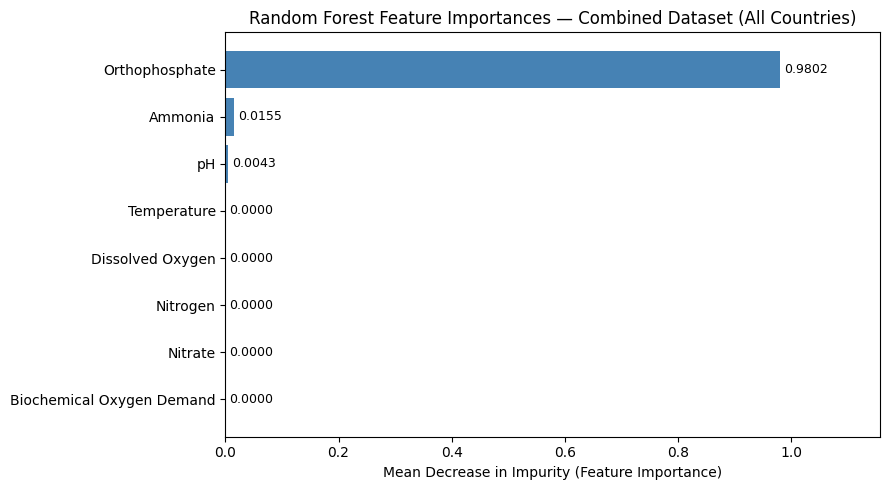

Saved to output/feature_importances.png


In [15]:
# ── Feature importance bar chart ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))
short_names = [n.split(" (")[0] for n in ranked_features]
bars = ax.barh(short_names, importances[sorted_idx], color="steelblue")
ax.set_xlabel("Mean Decrease in Impurity (Feature Importance)")
ax.set_title("Random Forest Feature Importances — Combined Dataset (All Countries)")
ax.bar_label(bars, fmt="%.4f", padding=3, fontsize=9)
ax.set_xlim(0, importances.max() * 1.18)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/feature_importances.png", dpi=150)
plt.show()
print(f"Saved to {OUTPUT_DIR}/feature_importances.png")

In [16]:
# ── Ablation: remove least important feature one by one ──────────────────────
# RF regressor; metric: R² on held-out test set

removal_order  = sorted_idx.tolist()   # least → most important
active_indices = list(range(len(FEATURES)))
results = []

for step in range(len(FEATURES)):
    col_idx  = active_indices[:]
    X_tr_sub = X_tr_s[:, col_idx]
    X_te_sub = X_te_s[:, col_idx]

    rf = RandomForestRegressor(n_estimators=100, random_state=RANDOM_SEED, n_jobs=-1)
    rf.fit(X_tr_sub, y_tr)
    y_pred_abl = rf.predict(X_te_sub)

    r2_abl  = r2_score(y_te, y_pred_abl)
    removed = FEATURES[removal_order[step - 1]] if step > 0 else "—"

    results.append({
        "n_features": len(active_indices),
        "removed":    removed,
        "r2":         r2_abl,
        "rmse":       np.sqrt(mean_squared_error(y_te, y_pred_abl)),
    })
    print(f"n={len(active_indices):2d}  R²={r2_abl:.4f}  RMSE={results[-1]['rmse']:.4f}  (removed: {removed})")

    if active_indices:
        drop = removal_order[step]
        active_indices = [i for i in active_indices if i != drop]

results_df = pd.DataFrame(results)
print("\n", results_df[["n_features", "removed", "r2", "rmse"]].to_string(index=False))

n= 8  R²=1.0000  RMSE=0.0087  (removed: —)
n= 7  R²=1.0000  RMSE=0.0087  (removed: Biochemical Oxygen Demand (mg/l))
n= 6  R²=1.0000  RMSE=0.0087  (removed: Nitrate (mg/l))
n= 5  R²=1.0000  RMSE=0.0086  (removed: Nitrogen (mg/l))
n= 4  R²=1.0000  RMSE=0.0086  (removed: Dissolved Oxygen (mg/l))
n= 3  R²=1.0000  RMSE=0.0086  (removed: Temperature (cel))
n= 2  R²=0.9956  RMSE=0.3704  (removed: pH (ph units))
n= 1  R²=0.9797  RMSE=0.7914  (removed: Ammonia (mg/l))

  n_features                          removed       r2     rmse
          8                                — 0.999998 0.008670
          7 Biochemical Oxygen Demand (mg/l) 0.999998 0.008668
          6                   Nitrate (mg/l) 0.999998 0.008655
          5                  Nitrogen (mg/l) 0.999998 0.008649
          4          Dissolved Oxygen (mg/l) 0.999998 0.008636
          3                Temperature (cel) 0.999998 0.008624
          2                    pH (ph units) 0.995562 0.370393
          1                  

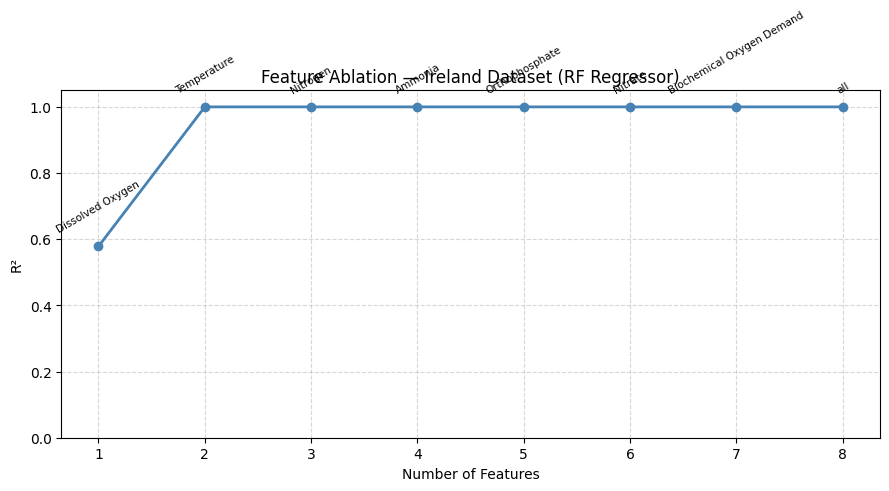

Saved to output/ablation_curve.png


In [ ]:
# ── Ablation curve ────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(results_df["n_features"], results_df["r2"], marker="o", linewidth=2, color="steelblue")
ax.set_xlabel("Number of Features")
ax.set_ylabel("R²")
ax.set_title("Feature Ablation — Combined Dataset (All Countries) (RF Regressor)")
ax.set_xticks(results_df["n_features"])
ax.set_ylim(0, 1.05)
ax.grid(True, linestyle="--", alpha=0.5)

for _, row in results_df.iterrows():
    label = row["removed"].split(" (")[0] if row["removed"] != "—" else "all"
    ax.annotate(label, xy=(row["n_features"], row["r2"]),
                xytext=(0, 10), textcoords="offset points",
                ha="center", fontsize=7.5, rotation=30)

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/ablation_curve.png", dpi=150)
plt.show()
print(f"Saved to {OUTPUT_DIR}/ablation_curve.png")

## Permutation Importance vs. MDI

Permutation importance measures how much macro F1 drops when a single feature's values are randomly shuffled on the **test set**. Unlike MDI, it is evaluated on held-out data and is not biased toward high-cardinality features.

In [ ]:
from sklearn.inspection import permutation_importance

# Uses rf_full trained on all 8 features; scoring = R²
perm = permutation_importance(
    rf_full, X_te_s, y_te,
    scoring="r2",
    n_repeats=10,
    random_state=RANDOM_SEED,
    n_jobs=-1,
)

perm_means = perm.importances_mean
perm_stds  = perm.importances_std

print("Permutation importance (mean drop in R²):")
perm_order = np.argsort(perm_means)
for i in perm_order:
    print(f"  {FEATURES[i]:45s}  {perm_means[i]:.4f} +/- {perm_stds[i]:.4f}")

Permutation importance (mean drop in R²):
  Ammonia (mg/l)                                 -0.0000 +/- 0.0000
  Nitrogen (mg/l)                                -0.0000 +/- 0.0000
  Orthophosphate (mg/l)                          -0.0000 +/- 0.0000
  Biochemical Oxygen Demand (mg/l)               0.0000 +/- 0.0000
  Nitrate (mg/l)                                 0.0000 +/- 0.0000
  Temperature (cel)                              0.0000 +/- 0.0000
  Dissolved Oxygen (mg/l)                        0.8361 +/- 0.0162
  pH (ph units)                                  1.1621 +/- 0.0125


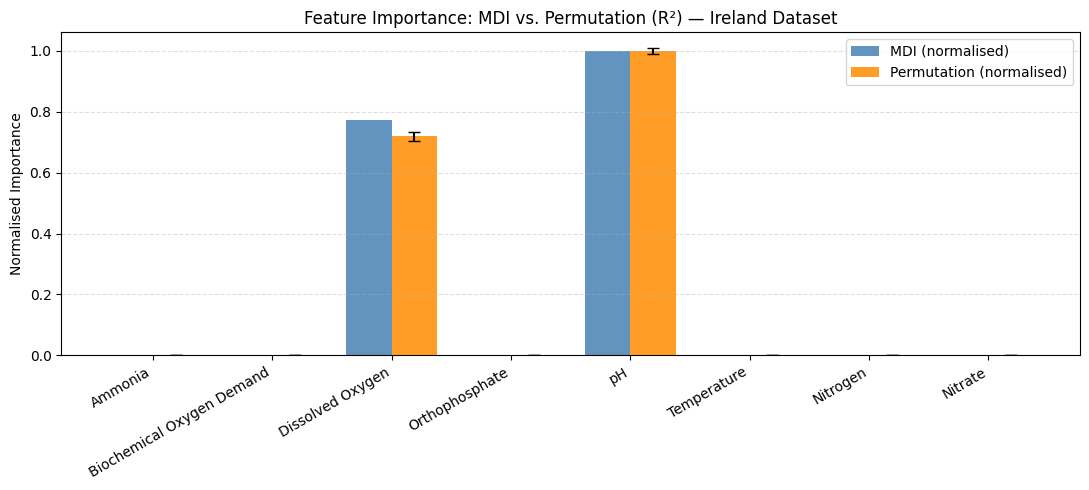

Saved to output/importance_comparison.png


In [ ]:
# ── Side-by-side MDI vs Permutation importance ───────────────────────────────
short = [n.split(" (")[0] for n in feat_names]

mdi_norm  = importances / importances.max()
perm_norm = perm_means  / perm_means.max() if perm_means.max() > 0 else perm_means

x     = np.arange(len(FEATURES))
width = 0.38

fig, ax = plt.subplots(figsize=(11, 5))
ax.bar(x - width/2, mdi_norm,  width, label="MDI (normalised)",        color="steelblue",  alpha=0.85)
ax.bar(x + width/2, perm_norm, width, label="Permutation (normalised)", color="darkorange", alpha=0.85,
       yerr=perm_stds / perm_means.max(), capsize=4)

ax.set_xticks(x)
ax.set_xticklabels(short, rotation=30, ha="right")
ax.set_ylabel("Normalised Importance")
ax.set_title("Feature Importance: MDI vs. Permutation (R²) — Combined Dataset (All Countries)")
ax.legend()
ax.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/importance_comparison.png", dpi=150)
plt.show()
print(f"Saved to {OUTPUT_DIR}/importance_comparison.png")

## ANN Ablation Study

Retrain the MLP from scratch for each feature subset (removal order determined by RF importance above). This gives the true degradation curve for the focus model.

In [ ]:
ann_results = []
active_indices = list(range(len(FEATURES)))

for step in range(len(FEATURES)):
    col_idx = active_indices[:]
    n_feat  = len(col_idx)

    # ── Scale features for this subset ───────────────────────────────────────
    sc_x = StandardScaler()
    X_tr_sub = sc_x.fit_transform(X_tr[:, col_idx])
    X_te_sub = sc_x.transform(X_te[:, col_idx])
    X_v_sub  = sc_x.transform(X_v[:, col_idx])

    sc_y = MinMaxScaler()
    y_tr_s = sc_y.fit_transform(y_tr.reshape(-1, 1)).flatten()
    y_v_s  = sc_y.transform(y_v.reshape(-1, 1)).flatten()

    # ── Build ANN ─────────────────────────────────────────────────────────────
    tf.random.set_seed(RANDOM_SEED)
    ann = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(n_feat,)),
        tf.keras.layers.Dense(128, activation="relu"),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Dropout(0.3),
        tf.keras.layers.Dense(64, activation="relu"),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Dropout(0.3),
        tf.keras.layers.Dense(32, activation="relu"),
        tf.keras.layers.Dropout(0.2),
        tf.keras.layers.Dense(1),
    ])
    ann.compile(optimizer=tf.keras.optimizers.Adam(1e-3), loss="mse", metrics=["mae"])

    cbs = [
        tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True),
        tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=5, min_lr=1e-6, verbose=0),
    ]

    ann.fit(X_tr_sub, y_tr_s, validation_data=(X_v_sub, y_v_s),
            epochs=100, batch_size=256, callbacks=cbs, verbose=0)

    # ── Evaluate ──────────────────────────────────────────────────────────────
    y_pred_s  = ann.predict(X_te_sub, verbose=0).flatten()
    y_pred    = sc_y.inverse_transform(y_pred_s.reshape(-1, 1)).flatten()

    r2_val   = r2_score(y_te, y_pred)
    rmse_val = np.sqrt(mean_squared_error(y_te, y_pred))
    removed  = FEATURES[removal_order[step - 1]] if step > 0 else "—"

    ann_results.append({
        "n_features": n_feat,
        "removed":    removed,
        "r2":         r2_val,
        "rmse":       rmse_val,
    })
    print(f"n={n_feat:2d}  R²={r2_val:.4f}  RMSE={rmse_val:.4f}  (removed: {removed})")

    if active_indices:
        drop = removal_order[step]
        active_indices = [i for i in active_indices if i != drop]

ann_results_df = pd.DataFrame(ann_results)
print("\n", ann_results_df[["n_features", "removed", "r2", "rmse"]].to_string(index=False))

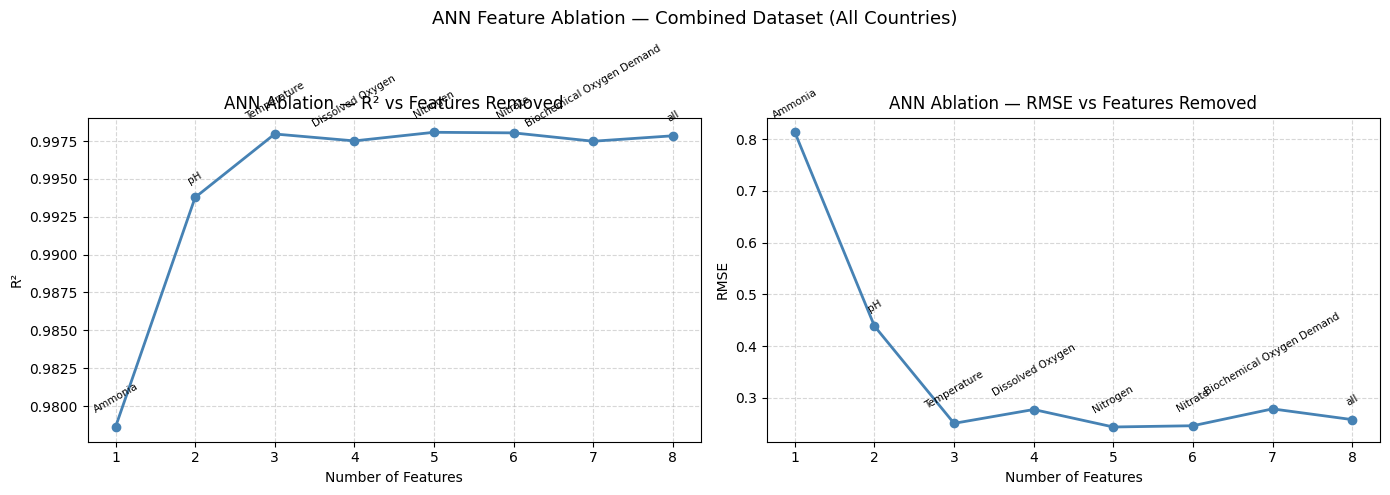

Saved to output/ablation_curve_ann.png


In [59]:
# ── ANN ablation curve ────────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

for ax, metric, label in [(ax1, "r2", "R²"), (ax2, "rmse", "RMSE")]:
    ax.plot(ann_results_df["n_features"], ann_results_df[metric],
            marker="o", linewidth=2, color="steelblue")
    ax.set_xlabel("Number of Features")
    ax.set_ylabel(label)
    ax.set_title(f"ANN Ablation — {label} vs Features Removed")
    ax.set_xticks(ann_results_df["n_features"])
    ax.grid(True, linestyle="--", alpha=0.5)

    for _, row in ann_results_df.iterrows():
        lbl = row["removed"].split(" (")[0] if row["removed"] != "—" else "all"
        ax.annotate(lbl, xy=(row["n_features"], row[metric]),
                    xytext=(0, 10), textcoords="offset points",
                    ha="center", fontsize=7.5, rotation=30)

plt.suptitle("ANN Feature Ablation — Combined Dataset (All Countries)", fontsize=13)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/ablation_curve_ann.png", dpi=150)
plt.show()
print(f"Saved to {OUTPUT_DIR}/ablation_curve_ann.png")

## LSTM Ablation Study

Same removal ordering as ANN (RF importance). 1 LSTM layer, 50 units, matching baseline architecture. Input reshaped to `(samples, 1, n_features)` for each subset.

In [17]:
lstm_results = []
active_indices = list(range(len(FEATURES)))

for step in range(len(FEATURES)):
    col_idx = active_indices[:]
    n_feat  = len(col_idx)

    # ── Scale ─────────────────────────────────────────────────────────────────
    sc_x = StandardScaler()
    X_tr_sub = sc_x.fit_transform(X_tr[:, col_idx]).reshape(-1, 1, n_feat)
    X_te_sub = sc_x.transform(X_te[:, col_idx]).reshape(-1, 1, n_feat)
    X_v_sub  = sc_x.transform(X_v[:, col_idx]).reshape(-1, 1, n_feat)

    sc_y = MinMaxScaler()
    y_tr_s = sc_y.fit_transform(y_tr.reshape(-1, 1)).flatten()
    y_v_s  = sc_y.transform(y_v.reshape(-1, 1)).flatten()

    # ── Build LSTM (matching baseline: 1 layer, 50 units) ─────────────────────
    tf.random.set_seed(RANDOM_SEED)
    lstm = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(1, n_feat)),
        tf.keras.layers.LSTM(50),
        tf.keras.layers.Dense(1),
    ])
    lstm.compile(optimizer=tf.keras.optimizers.Adam(1e-3), loss="mse", metrics=["mae"])

    cbs = [
        tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True),
        tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=5, min_lr=1e-6, verbose=0),
    ]

    lstm.fit(X_tr_sub, y_tr_s, validation_data=(X_v_sub, y_v_s),
             epochs=100, batch_size=256, callbacks=cbs, verbose=0)

    # ── Evaluate ──────────────────────────────────────────────────────────────
    y_pred_s = lstm.predict(X_te_sub, verbose=0).flatten()
    y_pred   = sc_y.inverse_transform(y_pred_s.reshape(-1, 1)).flatten()

    r2_val   = r2_score(y_te, y_pred)
    rmse_val = np.sqrt(mean_squared_error(y_te, y_pred))
    removed  = FEATURES[removal_order[step - 1]] if step > 0 else "—"

    lstm_results.append({
        "n_features": n_feat,
        "removed":    removed,
        "r2":         r2_val,
        "rmse":       rmse_val,
    })
    print(f"n={n_feat:2d}  R²={r2_val:.4f}  RMSE={rmse_val:.4f}  (removed: {removed})")

    if active_indices:
        drop = removal_order[step]
        active_indices = [i for i in active_indices if i != drop]

lstm_results_df = pd.DataFrame(lstm_results)
print("\n", lstm_results_df[["n_features", "removed", "r2", "rmse"]].to_string(index=False))

n= 8  R²=0.9905  RMSE=0.5409  (removed: —)
n= 7  R²=0.9909  RMSE=0.5309  (removed: Biochemical Oxygen Demand (mg/l))
n= 6  R²=0.9893  RMSE=0.5759  (removed: Nitrate (mg/l))
n= 5  R²=0.9888  RMSE=0.5875  (removed: Nitrogen (mg/l))
n= 4  R²=0.9893  RMSE=0.5756  (removed: Dissolved Oxygen (mg/l))
n= 3  R²=0.9885  RMSE=0.5952  (removed: Temperature (cel))
n= 2  R²=0.9863  RMSE=0.6503  (removed: pH (ph units))
n= 1  R²=0.9723  RMSE=0.9249  (removed: Ammonia (mg/l))

  n_features                          removed       r2     rmse
          8                                — 0.990537 0.540894
          7 Biochemical Oxygen Demand (mg/l) 0.990882 0.530926
          6                   Nitrate (mg/l) 0.989272 0.575907
          5                  Nitrogen (mg/l) 0.988834 0.587546
          4          Dissolved Oxygen (mg/l) 0.989282 0.575626
          3                Temperature (cel) 0.988540 0.595241
          2                    pH (ph units) 0.986319 0.650345
          1                  

NameError: name 'ann_results_df' is not defined

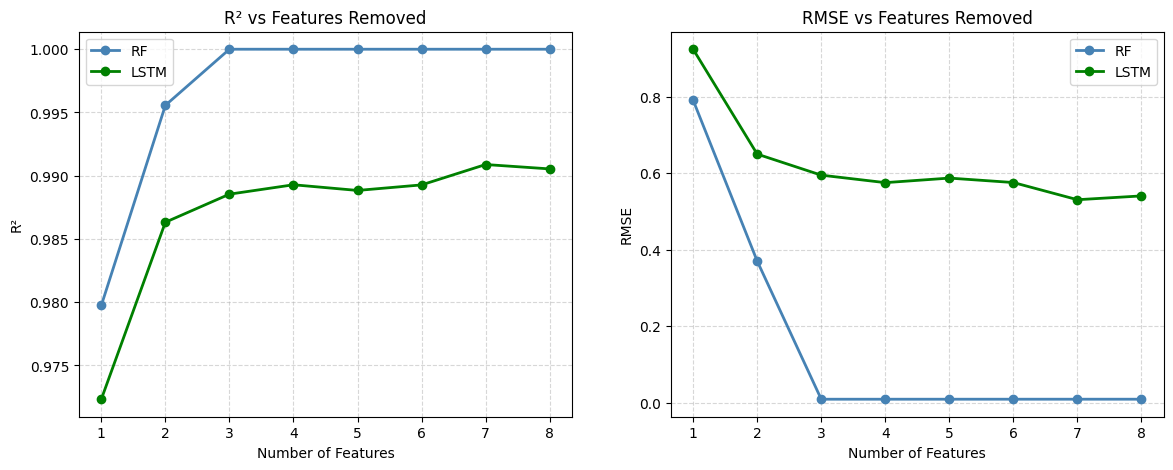

In [ ]:
# ── Combined 3-model ablation comparison ─────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

models = [
    (results_df,      "RF",   "steelblue"),
    (ann_results_df,  "ANN",  "darkorange"),
    (lstm_results_df, "LSTM", "green"),
]

for ax, metric, ylabel in [(ax1, "r2", "R²"), (ax2, "rmse", "RMSE")]:
    for df_m, label, color in models:
        ax.plot(df_m["n_features"], df_m[metric],
                marker="o", linewidth=2, label=label, color=color)
    ax.set_xlabel("Number of Features")
    ax.set_ylabel(ylabel)
    ax.set_title(f"{ylabel} vs Features Removed")
    ax.set_xticks(results_df["n_features"])
    ax.legend()
    ax.grid(True, linestyle="--", alpha=0.5)

# Annotate x-axis with feature removed at each step (use ANN df as reference)
x_labels = [r.split(" (")[0] if r != "—" else "all"
            for r in ann_results_df["removed"]]
for ax in (ax1, ax2):
    ax.set_xticklabels(
        [f"{n}\n({lbl})" for n, lbl in zip(ann_results_df["n_features"], x_labels)],
        fontsize=7.5
    )

plt.suptitle("Ablation Study: RF vs ANN vs LSTM — Combined Dataset (All Countries)", fontsize=13)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/ablation_comparison_all_models.png", dpi=150)
plt.show()
print(f"Saved to {OUTPUT_DIR}/ablation_comparison_all_models.png")

## Data Investigation: Which Parameters Drive the CCME Score?

We examine correlations, per-category distributions, and guideline failure rates to understand why Orthophosphate dominates the ablation results.

In [ ]:
# ── 1. Spearman correlation of each feature with CCME_Values ─────────────────
from scipy.stats import spearmanr
import pandas as pd

df_raw = pd.read_csv(DATA_PATH)

corr_rows = []
for feat in FEATURES:
    col = df_raw[feat].dropna()
    wqi = df_raw.loc[col.index, "CCME_Values"]
    r, p = spearmanr(col, wqi)
    corr_rows.append({"feature": feat.split(" (")[0], "spearman_r": r, "p_value": p})

corr_df = pd.DataFrame(corr_rows).sort_values("spearman_r", key=abs, ascending=False)
print("Spearman correlation with CCME_Values (absolute):")
print(corr_df.to_string(index=False))

NameError: name 'pd' is not defined

In [ ]:
# ── 2. Variance of each feature by WQI category ──────────────────────────────
cat_order = ["Excellent", "Good", "Fair", "Marginal", "Poor"]
short_feats = [f.split(" (")[0] for f in FEATURES]

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for ax, feat, short in zip(axes, FEATURES, short_feats):
    data = [df_raw[df_raw["CCME_WQI"] == cat][feat].dropna() for cat in cat_order]
    ax.boxplot(data, labels=cat_order, showfliers=False)
    ax.set_title(short, fontsize=10)
    ax.tick_params(axis="x", rotation=30, labelsize=8)

plt.suptitle("Feature Distribution by WQI Category — Combined Dataset", fontsize=13)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/feature_distributions_by_category.png", dpi=150)
plt.show()
print(f"Saved to {OUTPUT_DIR}/feature_distributions_by_category.png")

In [ ]:
# ── 3. Failure rate proxy: % of samples per feature that are outliers ─────────
# CCME counts "failures" as values that don't meet objectives.
# We approximate failure as values above the 95th percentile of each feature
# (high values = more likely to exceed guideline for pollutants like Orthophosphate).
# For DO and pH, low values indicate failure — handled separately.

low_fail  = {"Dissolved Oxygen (mg/l)", "pH (ph units)"}   # fail when LOW
high_fail = set(FEATURES) - low_fail                        # fail when HIGH

fail_rates = {}
for feat in FEATURES:
    if feat in high_fail:
        threshold = df_raw[feat].quantile(0.95)
        rate = (df_raw[feat] > threshold).mean() * 100
    else:
        threshold = df_raw[feat].quantile(0.05)
        rate = (df_raw[feat] < threshold).mean() * 100
    fail_rates[feat.split(" (")[0]] = rate

fail_df = pd.Series(fail_rates).sort_values(ascending=False)
print("Approximate failure rate (% samples exceeding directional 95th/5th percentile):")
print(fail_df.to_string())

fig, ax = plt.subplots(figsize=(9, 4))
fail_df.plot(kind="bar", ax=ax, color="steelblue", alpha=0.85)
ax.set_ylabel("% samples (proxy failure rate)")
ax.set_title("Proxy Failure Rate per Parameter — Combined Dataset")
ax.tick_params(axis="x", rotation=30)
ax.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/proxy_failure_rates.png", dpi=150)

NameError: name 'FEATURES' is not defined

## LSTM Ablation Study

Same removal ordering as ANN (RF importance). 1 LSTM layer, 50 units, matching baseline architecture.

In [ ]:
lstm_results = []
active_indices = list(range(len(FEATURES)))

for step in range(len(FEATURES)):
    col_idx = active_indices[:]
    n_feat  = len(col_idx)

    # ── Scale ─────────────────────────────────────────────────────────────────
    sc_x = StandardScaler()
    X_tr_sub = sc_x.fit_transform(X_tr[:, col_idx]).reshape(-1, 1, n_feat)
    X_te_sub = sc_x.transform(X_te[:, col_idx]).reshape(-1, 1, n_feat)
    X_v_sub  = sc_x.transform(X_v[:, col_idx]).reshape(-1, 1, n_feat)

    sc_y = MinMaxScaler()
    y_tr_s = sc_y.fit_transform(y_tr.reshape(-1, 1)).flatten()
    y_v_s  = sc_y.transform(y_v.reshape(-1, 1)).flatten()

    # ── Build LSTM (matching baseline: 1 layer, 50 units) ─────────────────────
    tf.random.set_seed(RANDOM_SEED)
    lstm = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(1, n_feat)),
        tf.keras.layers.LSTM(50),
        tf.keras.layers.Dense(1),
    ])
    lstm.compile(optimizer=tf.keras.optimizers.Adam(1e-3), loss="mse", metrics=["mae"])

    cbs = [
        tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True),
        tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=5, min_lr=1e-6, verbose=0),
    ]

    lstm.fit(X_tr_sub, y_tr_s, validation_data=(X_v_sub, y_v_s),
             epochs=100, batch_size=256, callbacks=cbs, verbose=0)

    # ── Evaluate ──────────────────────────────────────────────────────────────
    y_pred_s = lstm.predict(X_te_sub, verbose=0).flatten()
    y_pred   = sc_y.inverse_transform(y_pred_s.reshape(-1, 1)).flatten()

    r2_val   = r2_score(y_te, y_pred)
    rmse_val = np.sqrt(mean_squared_error(y_te, y_pred))
    removed  = FEATURES[removal_order[step - 1]] if step > 0 else "—"

    lstm_results.append({
        "n_features": n_feat,
        "removed":    removed,
        "r2":         r2_val,
        "rmse":       rmse_val,
    })
    print(f"n={n_feat:2d}  R²={r2_val:.4f}  RMSE={rmse_val:.4f}  (removed: {removed})")

    if active_indices:
        drop = removal_order[step]
        active_indices = [i for i in active_indices if i != drop]

lstm_results_df = pd.DataFrame(lstm_results)
print("\n", lstm_results_df[["n_features", "removed", "r2", "rmse"]].to_string(index=False))

NameError: name 'X_tr' is not defined

In [ ]:
# ── Combined 3-model ablation comparison ─────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

models = [
    (results_df,      "RF",   "steelblue"),
    (ann_results_df,  "ANN",  "darkorange"),
    (lstm_results_df, "LSTM", "green"),
]

for ax, metric, ylabel in [(ax1, "r2", "R²"), (ax2, "rmse", "RMSE")]:
    for df_m, label, color in models:
        ax.plot(df_m["n_features"], df_m[metric],
                marker="o", linewidth=2, label=label, color=color)
    ax.set_xlabel("Number of Features")
    ax.set_ylabel(ylabel)
    ax.set_title(f"{ylabel} vs Features Removed")
    ax.set_xticks(results_df["n_features"])
    ax.legend()
    ax.grid(True, linestyle="--", alpha=0.5)

# Annotate x-axis with feature removed at each step (use ANN df as reference)
x_labels = [r.split(" (")[0] if r != "—" else "all"
            for r in ann_results_df["removed"]]
for ax in (ax1, ax2):
    ax.set_xticklabels(
        [f"{n}\n({lbl})" for n, lbl in zip(ann_results_df["n_features"], x_labels)],
        fontsize=7.5
    )

plt.suptitle("Ablation Study: RF vs ANN vs LSTM — Combined Dataset (All Countries)", fontsize=13)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/ablation_comparison_all_models.png", dpi=150)
plt.show()
print(f"Saved to {OUTPUT_DIR}/ablation_comparison_all_models.png")